In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:

df = pd.read_csv("hotel_bookings.csv")
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


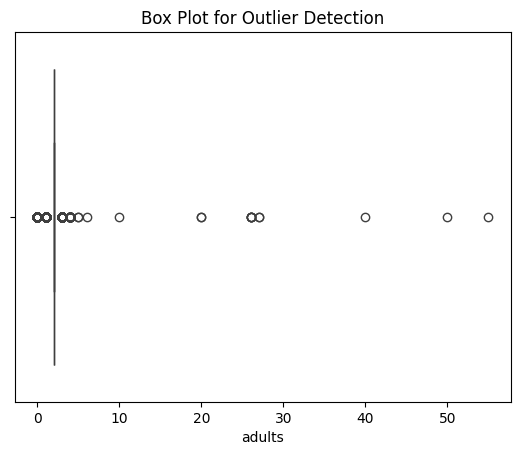

In [14]:
sns.boxplot(x=df['adults'])
plt.title('Box Plot for Outlier Detection')
plt.show()

In [ ]:
df['children'].fillna(0, inplace=True)

In [34]:
df['adults'].value_counts()
print("Original shape:", df.shape)
df = df[df['adults']< 10]
print("Shape after adults outlier removal:", df.shape)
df = df[df['children']< 5]
print("Shape after children outlier removal:", df.shape)
df = df[df['babies']< 10]
print("Shape after babies outlier removal:", df.shape)
df = df[df['adr']>= 0] 
df = df[df['adr'] < 1000]
print("Shape after adr outlier removal:", df.shape)
#1) remove 0-day stays
#2) remove 0-cost stays
#3) remove stays with no guests
#4) replace the NAs in the children variable with 0
df['children'].fillna(0, inplace=True)
df = df[
    (df['adr'] > 0)
    & ((df['stays_in_week_nights'] + df['stays_in_weekend_nights']) > 0)
    & ((df['adults'] + df['children'] + df['babies']) > 0)
    & df['children'].notna()
]
print("Shape after outlier removal:", df.shape)

Original shape: (119369, 32)
Shape after adults outlier removal: (119369, 32)
Shape after children outlier removal: (119369, 32)
Shape after babies outlier removal: (119369, 32)
Shape after adr outlier removal: (119369, 32)
Shape after outlier removal: (117392, 32)


C:\Users\Richard\AppData\Local\Temp\ipykernel_21160\3336596339.py:16: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['children'].fillna(0, inplace=True)


In [35]:
df.to_csv('hotel_bookings_clean.csv', index=False)